In [ ]:
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.ensemble import RandomForestClassifier     # Random Forest sklearn.metrics import classification_report, confusion_matrix
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [ ]:
data = pd.read_excel('Teddy_Data.xlsx')  # load data set
#data.drop(['S.no'],inplace=True,axis=1)
data

,S.no,Fever,Cough,Sore_throat,SOB,Flu,Body_aches,Loss_of_taste,Diarrhoea,Loss_of_smell,gender,status,wave
0,1,Yes,Yes,No,Mild,Yes,No,No,Yes,No,Female,Died,1
1,2,Yes,Yes,Mild,Severe,Yes,Mild,No,Yes,No,Male,Died,1
2,3,No,No,No,Mild,Yes,Severe,Yes,No,Yes,Male,Died,2
3,4,Yes,Yes,Severe,No,Yes,Severe,No,No,Yes,Female,Recovered,1
4,5,Yes,No,No,No,Yes,No,No,Yes,No,Male,Died,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Yes,No,Severe,Severe,Yes,Severe,Yes,No,No,Male,Died,2
2996,2997,Yes,No,No,No,Yes,Severe,Yes,Yes,No,Female,Died,3
2997,2998,Yes,No,Severe,Mild,No,No,No,Yes,No,Female,Died,1
2998,2999,Yes,Yes,Mild,Mild,No,Mild,Yes,Yes,Yes,Female,Recovered,1


In [ ]:
data.replace({"None":2}, inplace=True)
data["Fever"].replace({"No":0," Yes":1,"None":2}, inplace=True)
data["Cough"].replace({"No":0,"Yes":1,"None":2}, inplace=True)
data["Sore_throat"].replace({"Mild":0,"No":1,"Severe":2}, inplace=True)
data["SOB"].replace({"Mild":0,"No":1,"Severe":2}, inplace=True)
data["Flu"].replace({"No":0,"Yes":1,"None":2}, inplace=True)
data["Body_aches"].replace({"Mild":0,"No":1,"Severe":2}, inplace=True)
data["Loss_of_taste"].replace({"No":0,"Yes":1,"None":2}, inplace=True)
data["Diarrhoea"].replace({"No":0,"Yes":1,"None":2}, inplace=True)
data["Loss_of_smell"].replace({"No":0,"Yes":1,"None":2}, inplace=True)
data["gender"].replace({"Male":0,"Female":1}, inplace=True)
data["status"].replace({"Died":0,"Recovered":1,"other":2}, inplace=True)
X = data.iloc[:, [1,2,3,4,5,6,7,8,9,10,12]].values.reshape(-1,12)  # values converts it into a numpy array
Y = data.iloc[:, 11].values.reshape(-1, 1)  # -1 means that calculate the dimension of rows, but have 1 column
data

,S.no,Fever,Cough,Sore_throat,SOB,Flu,Body_aches,Loss_of_taste,Diarrhoea,Loss_of_smell,gender,status,wave
0,1,1,1,1,0,1,1,0,1,0,1,0,1
1,2,1,1,0,2,1,0,0,1,0,0,0,1
2,3,0,0,1,0,1,2,1,0,1,0,0,2
3,4,1,1,2,1,1,2,0,0,1,1,1,1
4,5,1,0,1,1,1,1,0,1,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,1,0,2,2,1,2,1,0,0,0,0,2
2996,2997,1,0,1,1,1,2,1,1,0,1,0,3
2997,2998,1,0,2,0,0,1,0,1,0,1,0,1
2998,2999,1,1,0,0,0,0,1,1,1,1,1,1


In [ ]:
#scaler =preprocessing.StandardScaler().fit(X)
#X=scaler.transform(X)
print(X)

[[1 1 1 ... 1 1 1]
 [1 0 2 ... 1 0 0]
 [1 0 1 ... 1 1 2]
 ...
 [0 1 3 ... 0 1 0]
 [1 1 1 ... 1 1 1]
 [1 1 0 ... 1 1 3]]


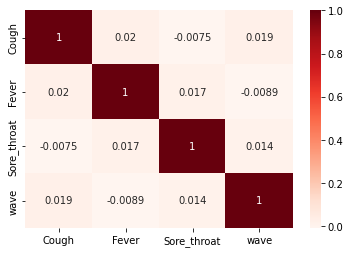

In [ ]:
import os
import seaborn as sns
data[['Cough','Fever','Sore_throat','wave']].corr()

#plot the correlation matrix of salary, balance and age in data dataframe.
sns.heatmap(data[['Cough','Fever','Sore_throat','wave']].corr(), annot=True, cmap = 'Reds')
plt.show()

,S.no,Fever,Cough,Sore_throat,SOB,Flu,Body_aches,Loss_of_taste,Diarrhoea,Loss_of_smell,gender,age,status,wave
S.no,1.000000,0.003949,-0.007703,-0.011510,0.009151,-0.020001,0.013295,0.020607,-0.000352,-0.014792,-0.008689,-0.021384,-0.004991,0.003684
Fever,0.003949,1.000000,0.019538,0.016972,-0.041587,0.002587,-0.023292,-0.047250,0.006641,-0.003974,-0.012243,0.010632,-0.005378,-0.008915
Cough,-0.007703,0.019538,1.000000,-0.007451,-0.004077,0.008707,0.023727,0.005287,0.006014,-0.016681,-0.039218,-0.025817,-0.002315,0.018842
Sore_throat,-0.011510,0.016972,-0.007451,1.000000,0.021731,-0.009665,-0.011445,-0.034940,-0.050883,0.034353,-0.009987,-0.006157,-0.019198,0.013885
SOB,0.009151,-0.041587,-0.004077,0.021731,1.000000,0.006522,-0.028048,-0.003261,0.002446,-0.022828,0.022014,0.007129,0.004895,0.034824
Flu,-0.020001,0.002587,0.008707,-0.009665,0.006522,1.000000,-0.015798,-0.001981,-0.001339,-0.021328,-0.013382,-0.041813,0.047222,-0.034545
Body_aches,0.013295,-0.023292,0.023727,-0.011445,-0.028048,-0.015798,1.000000,0.021503,0.018489,-0.016851,0.023053,0.005139,0.004418,-0.022156
Loss_of_taste,0.020607,-0.047250,0.005287,-0.034940,-0.003261,-0.001981,0.021503,1.000000,0.015340,0.003327,0.012724,-0.003624,0.005502,-0.003929
Diarrhoea,-0.000352,0.006641,0.006014,-0.050883,0.002446,-0.001339,0.018489,0.015340,1.000000,0.010668,-0.001349,-0.004591,0.000620,-0.013472
Loss_of_smell,-0.014792,-0.003974,-0.016681,0.034353,-0.022828,-0.021328,-0.016851,0.003327,0.010668,1.000000,0.001349,0.001156,0.008719,-0.010013


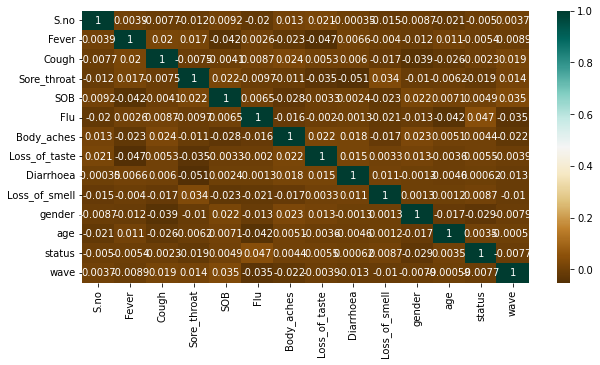

In [ ]:
plt.figure(figsize=(10,5))
c= data.corr()
sns.heatmap(c,cmap="BrBG",annot=True)
c

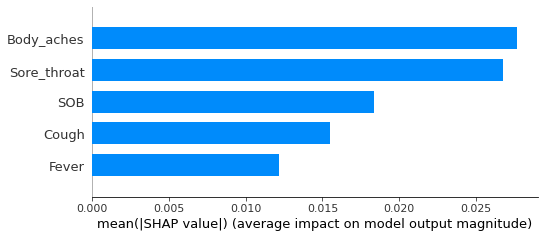

In [ ]:
import shap
shap_values = shap.TreeExplainer(model).shap_values(X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")

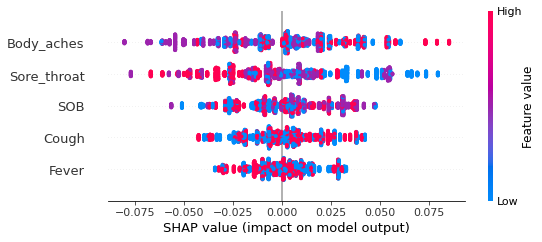

In [ ]:
shap.summary_plot(shap_values, X_train)

In [ ]:
import math
def matrix_metrix(real_values,pred_values,beta):
   CM = confusion_matrix(real_values,pred_values)
   TN = CM[0][0]
   FN = CM[1][0]
   TP = CM[1][1]
   FP = CM[0][1]
   Population = TN+FN+TP+FP
   Prevalence = round( (TP+FP) / Population,2)
   Accuracy   = round( (TP+TN) / Population,4)
   Precision  = round( TP / (TP+FP),4 )
   NPV        = round( TN / (TN+FN),4 )
   FDR        = round( FP / (TP+FP),4 )
   FOR        = round( FN / (TN+FN),4 )
   check_Pos  = Precision + FDR
   check_Neg  = NPV + FOR
   Recall     = round( TP / (TP+FN),4 )
   FPR        = round( FP / (TN+FP),4 )
   FNR        = round( FN / (TP+FN),4 )
   TNR        = round( TN / (TN+FP),4 )
   check_Pos2 = Recall + FNR
   check_Neg2 = FPR + TNR
   LRPos      = round( Recall/FPR,4 )
   LRNeg      = round( FNR / TNR ,4 )
   DOR        = round( LRPos/LRNeg)
   F1         = round ( 2 * ((Precision*Recall)/(Precision+Recall)),4)
   FBeta      = round ( (1+beta**2)*((Precision*Recall)/((beta**2 * Precision)+ Recall)) ,4)
   MCC        = round ( ((TP*TN)-(FP*FN))/math.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))  ,4)
   BM         = Recall+TNR-1
   MK         = Precision+NPV-1
   mat_met = pd.DataFrame({
'Metric':['TP','TN','FP','FN','Prevalence','Accuracy','Precision','NPV','FDR','FOR','check_Pos','check_Neg','Recall','FPR','FNR','TNR','check_Pos2','check_Neg2','LR+','LR-','DOR','F1','FBeta','MCC','BM','MK'],     'Value':[TP,TN,FP,FN,Prevalence,Accuracy,Precision,NPV,FDR,FOR,check_Pos,check_Neg,Recall,FPR,FNR,TNR,check_Pos2,check_Neg2,LRPos,LRNeg,DOR,F1,FBeta,MCC,BM,MK]})
   return (mat_met)

In [ ]:
beta = 0.5
mat_met = matrix_metrix(real_values,pred_values,beta)
print (mat_met)

        Metric     Value
0           TP  467.0000
1           TN  464.0000
2           FP   26.0000
3           FN   43.0000
4   Prevalence    0.4900
5     Accuracy    0.9310
6    Precision    0.9473
7          NPV    0.9152
8          FDR    0.0527
9          FOR    0.0848
10   check_Pos    1.0000
11   check_Neg    1.0000
12      Recall    0.9157
13         FPR    0.0531
14         FNR    0.0843
15         TNR    0.9469
16  check_Pos2    1.0000
17  check_Neg2    1.0000
18         LR+   17.2448
19         LR-    0.0890
20         DOR  194.0000
21          F1    0.9312
22       FBeta    0.9408
23         MCC    0.8625
24          BM    0.8626
25          MK    0.8625
